In [13]:
# !curl https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/sst.mnmean.nc -o data/sst.mnmean.nc
# !curl https://downloads.psl.noaa.gov/Datasets/noaa.ersst.v5/lsmask.nc -o data/lsmask.nc

In [14]:

import xarray as xr
ds=xr.open_dataset("data/sst.mnmean.nc")
print(ds)

<xarray.Dataset> Size: 133MB
Dimensions:    (time: 2071, nbnds: 2, lat: 89, lon: 180)
Coordinates:
  * time       (time) datetime64[ns] 17kB 1854-01-01 1854-02-01 ... 2026-07-01
  * lat        (lat) float32 356B 88.0 86.0 84.0 82.0 ... -84.0 -86.0 -88.0
  * lon        (lon) float32 720B 0.0 2.0 4.0 6.0 ... 352.0 354.0 356.0 358.0
Dimensions without coordinates: nbnds
Data variables:
    time_bnds  (time, nbnds) float64 33kB ...
    sst        (time, lat, lon) float32 133MB ...
Attributes: (12/37)
    climatology:               Climatology is based on 1971-2000 SST, Xue, Y....
    description:               In situ data: ICOADS2.5 before 2007 and NCEP i...
    keywords_vocabulary:       NASA Global Change Master Directory (GCMD) Sci...
    keywords:                  Earth Science > Oceans > Ocean Temperature > S...
    instrument:                Conventional thermometers
    source_comment:            SSTs were observed by conventional thermometer...
    ...                        ...
 

In [15]:
# To find the normal for each month
clim=ds["sst"].sel(time=slice("1991-01-01","2020-12-31")).groupby("time.month").mean("time")
#ds["sst"]data only pulls out the sst data  not anything else.
#sel(time=slice("1991-01-01","2020-12-31")) will keep the time slice for 30 years
#groupby will bins every timsestep by its calender month
#keep the mean of each group(12 months) for 30 years
print(clim)

<xarray.DataArray 'sst' (month: 12, lat: 89, lon: 180)> Size: 769kB
array([[[-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        ...,
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan],
        [       nan,        nan,        nan, ...,        nan,
                nan,        nan]],

       [[-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
        [-1.7999995, -1.7999995, -1.7999995, ..., -1.7999995,
         -1.7999995, -1.7999995],
...
        [       nan,        nan,        nan, ...,

In [16]:
#subtract the climatology from every month to get the anomaly, we need to subtract the climatology of its calender month for each timestamp
anom=ds["sst"].groupby("time.month")-clim
print(anom)

<xarray.DataArray 'sst' (time: 2071, lat: 89, lon: 180)> Size: 133MB
array([[[-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        ...,
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan],
        [           nan,            nan,            nan, ...,
                    nan,            nan,            nan]],

       [[-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.7683716e-07, -4.7683716e-07, -4.7683716e-07],
        [-4.7683716e-07, -4.7683716e-07, -4.7683716e-07, ...,
         -4.76

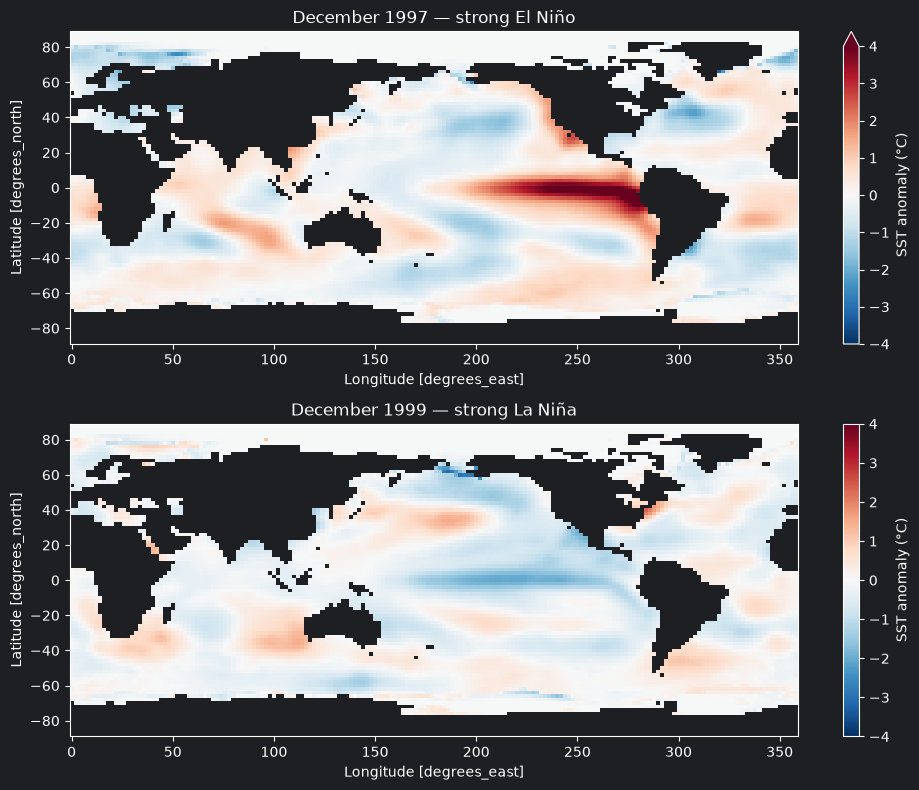

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(10, 8))

anom.sel(time="1997-12-01", method="nearest").plot(
    ax=axes[0], vmin=-4, vmax=4, cmap="RdBu_r", cbar_kwargs={"label": "SST anomaly (°C)"}
)
axes[0].set_title("December 1997 — strong El Niño")

anom.sel(time="1999-12-01", method="nearest").plot(
    ax=axes[1], vmin=-4, vmax=4, cmap="RdBu_r", cbar_kwargs={"label": "SST anomaly (°C)"}
)
axes[1].set_title("December 1999 — strong La Niña")

plt.tight_layout()
plt.show()

In [18]:
#download and parse the ONI
import urllib.request, os
os.makedirs("data",exist_ok=True)
urllib.request.urlretrieve("https://psl.noaa.gov/data/correlation/oni.data",
    "data/oni.data"
)
print("download oni.data")

download oni.data


In [19]:
#check
with open("data/oni.data") as f:
    lines=f.readlines()
for i, line in enumerate(lines[:5]):
    print(i,repr(line))
print("....")
for i, line in enumerate(lines[:5]):
    print(repr(line))

0 ' 1950         2026\n'
1 ' 1950  -1.53  -1.34  -1.16  -1.18  -1.07  -0.85  -0.54  -0.42  -0.39  -0.44  -0.60  -0.80\n'
2 ' 1951  -0.82  -0.54  -0.17   0.18   0.36   0.58   0.70   0.89   0.99   1.15   1.04   0.81\n'
3 ' 1952   0.53   0.37   0.34   0.29   0.20   0.00  -0.08   0.00   0.15   0.10   0.04   0.15\n'
4 ' 1953   0.40   0.60   0.63   0.66   0.75   0.77   0.75   0.73   0.78   0.84   0.84   0.81\n'
....
' 1950         2026\n'
' 1950  -1.53  -1.34  -1.16  -1.18  -1.07  -0.85  -0.54  -0.42  -0.39  -0.44  -0.60  -0.80\n'
' 1951  -0.82  -0.54  -0.17   0.18   0.36   0.58   0.70   0.89   0.99   1.15   1.04   0.81\n'
' 1952   0.53   0.37   0.34   0.29   0.20   0.00  -0.08   0.00   0.15   0.10   0.04   0.15\n'
' 1953   0.40   0.60   0.63   0.66   0.75   0.77   0.75   0.73   0.78   0.84   0.84   0.81\n'


In [20]:
#parse ONI into a tidy month series
import pandas as pd
import numpy as np

years = []
month_values = []   # list of 12-element lists

with open("data/oni.data") as f:
    for line in f:
        parts = line.split()
        if len(parts) == 13 and parts[0].isdigit() and len(parts[0]) == 4:
            years.append(int(parts[0]))
            month_values.append([float(v) for v in parts[1:]])  # 12 values

# Build a proper monthly date range from Jan of first year to Dec of last year
start = pd.Timestamp(year=years[0], month=1, day=1)
periods = len(years) * 12
dates = pd.date_range(start=start, periods=periods, freq="MS")  # MS = month start

# Flatten the 12-per-year grid into one long list, in order
flat_values = np.array(month_values).flatten()

oni = pd.Series(data=flat_values, index=dates, name="oni")
oni = oni.where(oni > -90)   # -99.9 flag -> NaN

print("LENGTH:", len(oni))
print("MONTHS:", sorted(set(oni.index.month)))
print(oni.loc["1950"])       # should show all 12 months of 1950

LENGTH: 924
MONTHS: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
1950-01-01   -1.53
1950-02-01   -1.34
1950-03-01   -1.16
1950-04-01   -1.18
1950-05-01   -1.07
1950-06-01   -0.85
1950-07-01   -0.54
1950-08-01   -0.42
1950-09-01   -0.39
1950-10-01   -0.44
1950-11-01   -0.60
1950-12-01   -0.80
Freq: MS, Name: oni, dtype: float64


## Labelling of data


In [21]:
# transform oni values into three classes
def oni_to_label(value):
    if value>=0.5:
        return 2
    elif value<= -0.5:
        return 0
    else:
        return 1

labels=oni.apply(oni_to_label).rename("label")
# Sanity check: how many months of each class?
counts = labels.value_counts().sort_index()
print("La Niña (0):", counts.get(0, 0))
print("Neutral (1):", counts.get(1, 0))
print("El Niño (2):", counts.get(2, 0))

La Niña (0): 252
Neutral (1): 424
El Niño (2): 248


In [22]:
# Align labels to SST maps on the INTERSECTION (months present in BOTH),
# because ONI runs to Dec 2026 but SST ends Jul 2026 — a plain .sel would fail.
# Then crop to the tropical Pacific box.
common = labels.index.intersection(anom.indexes["time"])

anom_aligned = anom.sel(time=common)
labels_aligned = labels.loc[common]

# Latitude runs 88 -> -88 (descending), so slice high-to-low. Lon 120–280°E in 0–360° space.
pacific = anom_aligned.sel(lat=slice(30, -30), lon=slice(120, 280))

print("aligned maps:", anom_aligned.sizes)
print("labels:", len(labels_aligned))
print("cropped maps:", pacific.sizes)

aligned maps: Frozen({'time': 919, 'lat': 89, 'lon': 180})
labels: 919
cropped maps: Frozen({'time': 919, 'lat': 31, 'lon': 81})


In [23]:
# Land cells are NaN. Fill with 0.0 = "no anomaly / normal" (valid because these are anomalies).
pacific_filled = pacific.fillna(0.0)

print("any NaNs now?", bool(np.isnan(pacific_filled).any()))
print("shape:", pacific_filled.sizes)

any NaNs now? False
shape: Frozen({'time': 919, 'lat': 31, 'lon': 81})


In [24]:
#Dataset class
import torch
from torch.utils.data import Dataset

class ENSODataset(Dataset):
    def __init__(self, maps, labels):
        self.X = maps.values.reshape(len(maps.time), -1).astype("float32")
        self.y = labels.values.astype("int64")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx])

In [25]:
#time based split and loaders
from torch.utils.data import DataLoader

split_date = "2010-01-01"
train_mask = labels_aligned.index <  split_date
test_mask  = labels_aligned.index >= split_date

X_train = pacific_filled.sel(time=labels_aligned.index[train_mask])
y_train = labels_aligned[train_mask]
X_test  = pacific_filled.sel(time=labels_aligned.index[test_mask])
y_test  = labels_aligned[test_mask]

print("train months:", len(y_train), "| test months:", len(y_test))
print("train classes:", y_train.value_counts().sort_index().to_dict())
print("test classes: ", y_test.value_counts().sort_index().to_dict())

train_ds = ENSODataset(X_train, y_train)
test_ds  = ENSODataset(X_test,  y_test)
train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_ds,  batch_size=32, shuffle=False)

train months: 720 | test months: 199
train classes: {0: 195, 1: 329, 2: 196}
test classes:  {0: 57, 1: 90, 2: 52}


In [26]:
#The network
import torch.nn as nn

input_size = pacific_filled.sizes["lat"] * pacific_filled.sizes["lon"]  # 31*81 = 2511
num_classes = 3

class ENSOClassifier(nn.Module):
    def __init__(self, input_size, num_classes):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        return self.net(x)

model = ENSOClassifier(input_size, num_classes)
print(model)
print("input size:", input_size)

ENSOClassifier(
  (net): Sequential(
    (0): Linear(in_features=2511, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=3, bias=True)
  )
)
input size: 2511


In [27]:
#training loop
import torch.nn as nn

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

n_epochs = 30

for epoch in range(n_epochs):
    model.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()             # clear gradients from last step
        outputs = model(X_batch)          # forward pass -> logits
        loss = criterion(outputs, y_batch)  # compare logits to true labels
        loss.backward()                   # backprop: compute gradients
        optimizer.step()                  # update weights
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    if (epoch + 1) % 5 == 0:              # print every 5 epochs
        print(f"epoch {epoch+1:2d}/{n_epochs}  |  loss {avg_loss:.4f}")

epoch  5/30  |  loss 0.2004
epoch 10/30  |  loss 0.0867
epoch 15/30  |  loss 0.0553
epoch 20/30  |  loss 0.0140
epoch 25/30  |  loss 0.0036
epoch 30/30  |  loss 0.0020


In [28]:
#evaluation
from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

model.eval()
all_preds, all_true = [], []

with torch.no_grad():                     # no gradients needed for evaluation
    for X_batch, y_batch in test_loader:
        outputs = model(X_batch)
        preds = outputs.argmax(dim=1)     # pick the highest-scoring class
        all_preds.extend(preds.numpy())
        all_true.extend(y_batch.numpy())

all_preds = np.array(all_preds)
all_true = np.array(all_true)

accuracy = (all_preds == all_true).mean()
print(f"TEST ACCURACY: {accuracy:.1%}   (baseline to beat: 45.2%)")
print()

class_names = ["La Niña", "Neutral", "El Niño"]
cm = confusion_matrix(all_true, all_preds)
print("Confusion matrix (rows = true, cols = predicted):")
print("            ", "  ".join(f"{n:>8}" for n in class_names))
for i, name in enumerate(class_names):
    print(f"{name:>10}  ", "  ".join(f"{cm[i,j]:>8}" for j in range(3)))
print()
print(classification_report(all_true, all_preds, target_names=class_names))

TEST ACCURACY: 77.4%   (baseline to beat: 45.2%)

Confusion matrix (rows = true, cols = predicted):
              La Niña   Neutral   El Niño
   La Niña         51         6         0
   Neutral         15        67         8
   El Niño          0        16        36

              precision    recall  f1-score   support

     La Niña       0.77      0.89      0.83        57
     Neutral       0.75      0.74      0.75        90
     El Niño       0.82      0.69      0.75        52

    accuracy                           0.77       199
   macro avg       0.78      0.78      0.78       199
weighted avg       0.78      0.77      0.77       199



In [29]:
#a CNN shaped dataset
import torch
import numpy as np
from torch.utils.data import Dataset, DataLoader
class ENSODatasetCNN(Dataset):
    def __init__(self, maps, labels):
        # Keep 2D shape, add a channel dimension: (N, 1, lat, lon) — like 1-channel images
        arr = maps.values.astype("float32")           # (time, lat, lon)
        self.X = arr[:, np.newaxis, :, :]             # (time, 1, lat, lon)
        self.y = labels.values.astype("int64")

    def __len__(self):
        return len(self.y)

    def __getitem__(self, idx):
        return torch.from_numpy(self.X[idx]), torch.tensor(self.y[idx])

# Rebuild loaders with the CNN-shaped dataset (same time-based split as before)
train_ds_cnn = ENSODatasetCNN(X_train, y_train)
test_ds_cnn  = ENSODatasetCNN(X_test,  y_test)
train_loader_cnn = DataLoader(train_ds_cnn, batch_size=32, shuffle=True)
test_loader_cnn  = DataLoader(test_ds_cnn,  batch_size=32, shuffle=False)

# Check the shape of one batch
xb, yb = next(iter(train_loader_cnn))
print("batch shape:", xb.shape)   # expect (32, 1, 31, 81)


batch shape: torch.Size([32, 1, 31, 81])


In [31]:
#CNN model
class ENSOCNNClassifier(nn.Module):
    def __init__(self, num_classes=3):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),   # 1 channel -> 8 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2),                              # halve spatial size
            nn.Conv2d(8, 16, kernel_size=3, padding=1),  # 8 -> 16 feature maps
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyLinear(64),      # LazyLinear infers its input size automatically
            nn.ReLU(),
            nn.Linear(64, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model_cnn = ENSOCNNClassifier()
# Initialize the lazy layer by running one batch through
_ = model_cnn(xb)
print(model_cnn)

ENSOCNNClassifier(
  (features): Sequential(
    (0): Conv2d(1, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2240, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=3, bias=True)
  )
)


In [32]:
#Train
criterion = nn.CrossEntropyLoss()
optimizer_cnn = torch.optim.Adam(model_cnn.parameters(), lr=0.001)

n_epochs = 30
for epoch in range(n_epochs):
    model_cnn.train()
    running_loss = 0.0
    for X_batch, y_batch in train_loader_cnn:
        optimizer_cnn.zero_grad()
        outputs = model_cnn(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer_cnn.step()
        running_loss += loss.item()
    if (epoch + 1) % 5 == 0:
        print(f"epoch {epoch+1:2d}/{n_epochs}  |  loss {running_loss/len(train_loader_cnn):.4f}")

epoch  5/30  |  loss 0.1827
epoch 10/30  |  loss 0.1465
epoch 15/30  |  loss 0.1061
epoch 20/30  |  loss 0.1196
epoch 25/30  |  loss 0.1035
epoch 30/30  |  loss 0.0471


In [34]:
#Evaluate
from sklearn.metrics import confusion_matrix, classification_report

model_cnn.eval()
all_preds, all_true = [], []
with torch.no_grad():
    for X_batch, y_batch in test_loader_cnn:
        preds = model_cnn(X_batch).argmax(dim=1)
        all_preds.extend(preds.numpy())
        all_true.extend(y_batch.numpy())

all_preds, all_true = np.array(all_preds), np.array(all_true)
accuracy = (all_preds == all_true).mean()
print(f"CNN TEST ACCURACY: {accuracy:.1%}   (feedforward was 76.4%, baseline 45.2%)")
print()

class_names = ["La Niña", "Neutral", "El Niño"]
cm = confusion_matrix(all_true, all_preds)
print("Confusion matrix (rows = true, cols = predicted):")
print("            ", "  ".join(f"{n:>8}" for n in class_names))
for i, name in enumerate(class_names):
    print(f"{name:>10}  ", "  ".join(f"{cm[i,j]:>8}" for j in range(3)))
print()
print(classification_report(all_true, all_preds, target_names=class_names))

CNN TEST ACCURACY: 83.9%   (feedforward was 76.4%, baseline 45.2%)

Confusion matrix (rows = true, cols = predicted):
              La Niña   Neutral   El Niño
   La Niña         38        19         0
   Neutral          1        82         7
   El Niño          0         5        47

              precision    recall  f1-score   support

     La Niña       0.97      0.67      0.79        57
     Neutral       0.77      0.91      0.84        90
     El Niño       0.87      0.90      0.89        52

    accuracy                           0.84       199
   macro avg       0.87      0.83      0.84       199
weighted avg       0.86      0.84      0.84       199

